# Converting a mesh between formats with meshio++ (Julia)

Julia counterpart of [`02_convert_and_inspect.ipynb`](../cpp/02_convert_and_inspect.ipynb). meshio++'s
registry dispatches to any of its 40+ format writers from one table; here we take the bracket geometry,
write it to several formats through `mio.write`, compare sizes, and verify every round trip.

XDMF's data format depends on the build (`MESHIOPLUSPLUS_HAS_HDF5`); the C API this binding uses for these
notebooks is built with HDF5 off (see [`README.md`](./README.md) for why — a real Debian/Ubuntu + Julia
`libcurl` conflict, not a meshio++ bug), so XDMF falls back to inline XML automatically.

In [1]:
ENV["MESHIOPLUSPLUS_LIB"] = joinpath(@__DIR__, "..", "..", "inst-nohdf5", "lib", "libmeshioplusplus.so")
import Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", "bindings", "julia", "MeshioPlusPlus"))
using MeshioPlusPlus
import MeshioPlusPlus as mio
include("mio_notebook.jl")

  Activating 

project at `~/src/meshioplusplus/bindings/julia/MeshioPlusPlus`


histogram_chart

In [2]:
mesh = mio.read(joinpath(@__DIR__, "example.vtu"))
println(num_points(mesh), " points, ", cell_block_info(mesh, 1).num_cells, " triangles, ",
        cell_block_info(mesh, 2).num_cells, " tetrahedra")

52282 points, 

58394 triangles, 235014 tetrahedra


## Convert to several formats

In [3]:
tmpdir = mktempdir()
targets = [
    ("vtu"  , joinpath(tmpdir, "mesh.vtu")),
    ("vtk"  , joinpath(tmpdir, "mesh.vtk")),
    ("xdmf" , joinpath(tmpdir, "mesh.xdmf")),
    ("gmsh" , joinpath(tmpdir, "mesh.msh")),
    ("ply"  , joinpath(tmpdir, "mesh.ply")),
]
for (fmt, path) in targets
    mio.write(mesh, path; format=fmt)
end

sizes_mb = [filesize(path) / 1e6 for (_, path) in targets]
for ((fmt, path), sz) in zip(targets, sizes_mb)
    println(rpad(fmt, 6), lpad(round(sz; digits=2), 8), " MB")
end

vtu       4.76

meshio warning [ply.cpp:404] PLY: writing the extracted skin of the volume cells; 1 pre-existing non-volume cell block(s) dropped (pass skin=false for the legacy behavior).


 MB
vtk       13.7 MB
xdmf     10.81 MB
gmsh     12.94 MB
ply       1.46 MB


## Compare file sizes

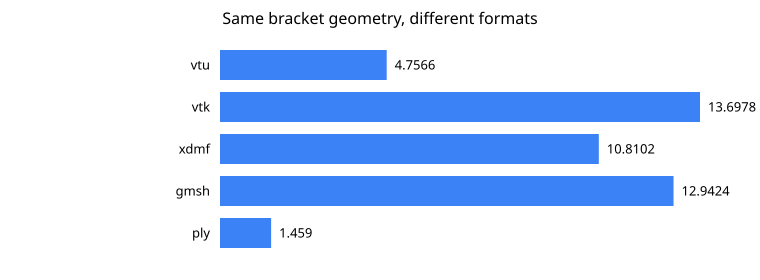

In [4]:
bar_chart([fmt for (fmt, _) in targets], sizes_mb, "Same bracket geometry, different formats")

## Round-trip verification

Read every file back and check the point/cell counts survive. `ply` is the expected exception: meshio++'s
PLY writer defaults to writing the extracted, linearized **skin** (triangles only), not the original
triangle+tetra blocks, so its round trip is compared against the skin instead.

In [5]:
n_pts = num_points(mesh)
n_cells = num_cells(mesh)
skin = extract_skin(mesh; linearize=true)

for (fmt, path) in targets
    back = mio.read(path; format=fmt)
    bpts = num_points(back)
    bcells = num_cells(back)
    is_ply = fmt == "ply"
    expect_pts = is_ply ? num_points(skin) : n_pts
    expect_cells = is_ply ? num_cells(skin) : n_cells
    ok = bpts == expect_pts && bcells == expect_cells
    println(ok ? "OK  " : "DIFF", " ", rpad(fmt, 6), " points=", bpts, " cells=", bcells)
end

OK   

vtu    points=52282 cells=293408
OK   vtk    points=52282 cells=293408
OK   xdmf   points=52282 cells=293408
OK   gmsh   points=52282 cells=293408
OK   ply    points=29151 cells=58394


Every format round-trips the geometry it is capable of carrying — the same registry, the same
writers, the same guarantees as the C++/Python/Fortran bindings; only the calling convention differs.